# 静态场景 - 比例扫描实验
固定总密度，扫描不同业务比例下的性能表现

## 初始化环境

In [1]:
import sys
sys.path.insert(0, '.')

from algo.logger import reset_logger
reset_logger()

In [2]:
from dataclasses import replace
from pathlib import Path
from typing import Dict
from copy import deepcopy
import math
import torch
import yaml
import os
import numpy as np
from collections import OrderedDict
import importlib
from matplotlib import pyplot as plt

from algo import HPPOConfig, build_hppo_modules, train_hppo
from algo.logger import get_logger, setup_logger
from env import (
    MACSimulatorConfig,
    SatelliteMACEnv,
    SatelliteMACEnvConfig,
    default_simulator_config,
    build_gym_env,
)
import matplotlib.font_manager as font_manager
import scienceplots
plt.style.use(['science', 'no-latex'])
plt.rcParams['font.family'] = ['sans-serif']
plt.rcParams['font.sans-serif'] = ['Noto Sans SC',]

# 导入评估工具（使用新的分离函数）
from utils.evaluate import (
    static_sensitivity_config,
    train_scenario,
    evaluate_scenario_ppo,
    evaluate_scenario_baseline,
    print_results_summary,
    load_yaml_config
)
import baseline
importlib.reload(baseline)
from baseline import run_episode


## 比例扫描配置生成

In [3]:
def run_ratio_sweep_experiment():
    """
    比例扫描实验：固定总密度，扫描业务比例
    用于绘制：Performance vs. CBRA_Ratio 曲线
    """
    # 1. 固定总密度
    fixed_density = 40.0

    # 2. 固定 CFRA (通常控制开销比较固定，这里假设为 15%)
    fixed_cfra = 0.15

    # 剩余的 85% 容量将在 CBRA 和 PBRA 之间分配
    remaining_capacity = 1.0 - fixed_cfra

    # 3. 扫描 CBRA 在剩余容量中的占比 (10% -> 90%)
    alpha_steps = np.linspace(0.1, 0.9, 5)  # [0.1, ... 0.9]

    configs = []

    print(f"--- Generating Ratio Sweep Configs (Density={fixed_density}) ---")
    for alpha in alpha_steps:
        # 计算 CBRA 和 PBRA
        cbra = remaining_capacity * alpha
        pbra = remaining_capacity * (1.0 - alpha)

        # 简单的浮点数修正，防止相加不等于 1.0
        current_sum = cbra + pbra + fixed_cfra
        if abs(current_sum - 1.0) > 1e-9:
            pbra += (1.0 - current_sum)

        # 生成配置
        cfg = static_sensitivity_config(
            total_density=fixed_density,
            cbra_ratio=cbra,
            pbra_ratio=pbra,
            cfra_ratio=fixed_cfra
        )

        label = f"RatioSweep_C{cbra:.2f}_P{pbra:.2f}"
        configs.append((label, cfg))
        print(f"Generated: {label} (CBRA={cbra:.2f}, PBRA={pbra:.2f}, CFRA={fixed_cfra:.2f})")

    return configs

# 生成配置
ratio_sweep_configs = run_ratio_sweep_experiment()
print(f"\n总共生成 {len(ratio_sweep_configs)} 个比例扫描场景配置")

--- Generating Ratio Sweep Configs (Density=40.0) ---
Generated: RatioSweep_C0.09_P0.77 (CBRA=0.09, PBRA=0.77, CFRA=0.15)
Generated: RatioSweep_C0.26_P0.59 (CBRA=0.26, PBRA=0.59, CFRA=0.15)
Generated: RatioSweep_C0.42_P0.42 (CBRA=0.42, PBRA=0.42, CFRA=0.15)
Generated: RatioSweep_C0.60_P0.25 (CBRA=0.60, PBRA=0.25, CFRA=0.15)
Generated: RatioSweep_C0.77_P0.08 (CBRA=0.77, PBRA=0.08, CFRA=0.15)

总共生成 5 个比例扫描场景配置


## 加载训练配置

In [4]:
CONFIG_PATH = Path("conf/default.yaml")

raw_config = load_yaml_config(CONFIG_PATH)
seed = int(raw_config.get("seed", 20251202))
torch.manual_seed(seed)

log_section = raw_config.get("logging", {})
log_file = f"logs/{seed}_ratio_sweep.log"
try:
    os.remove(log_file) if os.path.exists(log_file) else None
except Exception as e:
    print(f'Warning {e}')
log_level = log_section.get("level", "INFO")
setup_logger(log_file, log_level)
my_logger = get_logger()
my_logger.info(f"Logger initialized for ratio sweep experiment")

# 环境配置
env_section = dict(raw_config.get("environment", {}))
algo_section = raw_config.get("algorithm", {})
env_section.setdefault("noise_scale", 0.01)

simulator_config = default_simulator_config()
num_slots_per_step = int(env_section.get("num_slots_per_step", 10))

env_config = SatelliteMACEnvConfig(
    num_slots_per_step=num_slots_per_step,
    decision_horizon=100,
    preamble_delta_range=int(env_section.get("preamble_delta_range", 2)),
    flatten_observation=bool(env_section.get("flatten_observation", True)),
    simulator_config=simulator_config,
)

num_envs = 8
env_backend = "parallel"

train_config = HPPOConfig(
    frames_per_batch=3200,
    mini_batch_size=256,
    rollout_epochs=4,
    max_iterations=2000,  # 静态场景训练100轮
    gamma=float(algo_section.get("gamma", 0.99)),
    gae_lambda=float(algo_section.get("gae_lambda", 0.95)),
    clip_epsilon=0.2,
    entropy_coeff=0.1,
    actor_lr=3e-4,
    critic_lr=3e-4,
    device=torch.device(algo_section.get("device", "cpu")),
)

my_logger.info(f"Config ready | seed={seed} num_envs={num_envs}")
print(f"配置加载完成: {len(ratio_sweep_configs)} 个场景待训练")


2025-12-04 23:31:25 | INFO     | Logger initialized for ratio sweep experiment


Loaded configuration from conf\default.yaml
配置加载完成: 5 个场景待训练


2025-12-04 23:31:25 | INFO     | Config ready | seed=42 num_envs=8


## 执行比例扫描训练

In [5]:
# 全局结果存储
all_train_results = OrderedDict()  # 存储训练结果

print(f"\n{'='*80}")
print(f"开始批量训练 {len(ratio_sweep_configs)} 个比例扫描场景")
print(f"{'='*80}\n")

for idx, (label, sim_config) in enumerate(ratio_sweep_configs):
    print(f"\n[{idx+1}/{len(ratio_sweep_configs)}] 当前场景: {label}")
    try:
        # 训练模型
        train_result = train_scenario(
            scenario_name=label,
            sim_config=sim_config,
            env_config=env_config,
            train_config=train_config,
            build_env_func=build_gym_env,
            build_modules_func=build_hppo_modules,
            train_func=train_hppo,
            logger=my_logger,
            num_envs=num_envs,
            env_backend=env_backend,
            seed=seed
        )

        all_train_results[label] = train_result
        print(f"✓ 场景 {label} 训练完成")

    except Exception as e:
        print(f"✗ 场景 {label} 训练失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景训练完成!")
print(f"成功训练场景数: {len(all_train_results)}/{len(ratio_sweep_configs)}")
print(f"{'='*80}")



开始批量训练 5 个比例扫描场景


[1/5] 当前场景: RatioSweep_C0.09_P0.77

开始训练场景: RatioSweep_C0.09_P0.77
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D40.0_C0.1_P0.8_F0.1', cbra_density=np.float64(3.4000000000000004), pbra_density=np.float64(30.6), cfra_density=6.0),), segments=(RegionSegment(region_name='static_D40.0_C0.1_P0.8_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_threshold_high=0.16, max_backlog_steps=48)), preamble_delta_range=2, flatten_observation=True)
config 2
2025-12-04 23:31:25,200 [torch

e:\CourseData\博士\二上\i3c\20251027-星网总结报告\hppo-mac\.venv\Lib\site-packages\torchrl\envs\batched_envs.py:2318: UserWarning: Sending a seeded ParallelEnv to another device requires re-seeding it. Re-seeding envs to [42, 1445067485, 3334094167, 3585780589, 2792652595, 3481998204, 395747745, 79072177].
  warn(
2025-12-04 23:31:31 | INFO     | Starting PPO training for scenario: RatioSweep_C0.09_P0.77


  iter=0000, reward=-4.8874
  iter=0010, reward=-0.6763
  iter=0020, reward=-0.4760
  iter=0030, reward=-0.3622
  iter=0040, reward=-0.2890
  iter=0050, reward=-0.2742
  iter=0060, reward=-0.1046
  iter=0070, reward=-0.0320
  iter=0080, reward=0.0013
  iter=0090, reward=0.1420
  iter=0100, reward=0.2362
  iter=0110, reward=0.3783
  iter=0120, reward=0.3678
  iter=0130, reward=0.6518
  iter=0140, reward=0.5461
  iter=0150, reward=0.6760
  iter=0160, reward=0.7502
  iter=0170, reward=0.8650
  iter=0180, reward=1.0238
  iter=0190, reward=1.2106
  iter=0200, reward=1.3006
  iter=0210, reward=1.3486
  iter=0220, reward=1.4221
  iter=0230, reward=0.7258
  iter=0240, reward=1.0577
  iter=0250, reward=1.3449
  iter=0260, reward=1.3900
  iter=0270, reward=1.4844
  iter=0280, reward=1.3944
  iter=0290, reward=1.4570
  iter=0300, reward=1.4989
  iter=0310, reward=1.5733
  iter=0320, reward=1.6727
  iter=0330, reward=1.6788
  iter=0340, reward=1.6408
  iter=0350, reward=1.7545
  iter=0360, reward=

2025-12-05 02:08:01 | INFO     | Starting PPO training for scenario: RatioSweep_C0.26_P0.59


  iter=0000, reward=-3.2408
  iter=0010, reward=-0.4577
  iter=0020, reward=-0.2589
  iter=0030, reward=-0.1245
  iter=0040, reward=0.2238
  iter=0050, reward=0.0925
  iter=0060, reward=0.2880
  iter=0070, reward=0.4245
  iter=0080, reward=0.9362
  iter=0090, reward=0.9042
  iter=0100, reward=1.0537
  iter=0110, reward=1.1179
  iter=0120, reward=1.2301
  iter=0130, reward=1.5226
  iter=0140, reward=1.0848
  iter=0150, reward=1.5306
  iter=0160, reward=1.6884
  iter=0170, reward=0.4716
  iter=0180, reward=1.0160
  iter=0190, reward=1.5073
  iter=0200, reward=1.6530
  iter=0210, reward=1.4208
  iter=0220, reward=1.7263
  iter=0230, reward=1.7796
  iter=0240, reward=1.7730
  iter=0250, reward=1.8867
  iter=0260, reward=1.4795
  iter=0270, reward=1.8316
  iter=0280, reward=1.8838
  iter=0290, reward=1.8757
  iter=0300, reward=1.9764
  iter=0310, reward=1.9444
  iter=0320, reward=1.5874
  iter=0330, reward=1.9198
  iter=0340, reward=1.9450
  iter=0350, reward=2.0040
  iter=0360, reward=1.87

...

  iter=0000, reward=-0.6651
  iter=0010, reward=-0.3901
  iter=0020, reward=-0.0957
  iter=0030, reward=0.1609
  iter=0040, reward=0.4514
  iter=0050, reward=0.8150
  iter=0060, reward=0.8752
  iter=0070, reward=1.1817
  iter=0080, reward=1.5041
  iter=0090, reward=1.4499
  iter=0100, reward=1.6884
  iter=0110, reward=1.7426
  iter=0120, reward=1.8639
  iter=0130, reward=1.8182
  iter=0140, reward=1.7903
  iter=0150, reward=1.9175
  iter=0160, reward=1.9731
  iter=0170, reward=1.9776
  iter=0180, reward=2.0061
  iter=0190, reward=2.0040
  iter=0200, reward=2.0292
  iter=0210, reward=1.4784
  iter=0220, reward=1.8264
  iter=0230, reward=1.9923
  iter=0240, reward=2.0454
  iter=0250, reward=2.0533
  iter=0260, reward=1.3194
  iter=0270, reward=1.8103
  iter=0280, reward=1.9939
  iter=0290, reward=0.9837
  iter=0300, reward=1.5603
  iter=0310, reward=1.7770
  iter=0320, reward=1.9680
  iter=0330, reward=2.0806
  iter=0340, reward=0.7795
  iter=0350, reward=1.2465
  iter=0360, reward=1.517

2025-12-05 07:22:20 | INFO     | Starting PPO training for scenario: RatioSweep_C0.60_P0.25


  iter=0000, reward=-0.9910
  iter=0010, reward=-0.4765
  iter=0020, reward=-0.2865
  iter=0030, reward=-0.0578
  iter=0040, reward=-0.0340
  iter=0050, reward=0.1719
  iter=0060, reward=0.2149
  iter=0070, reward=0.4554
  iter=0080, reward=0.5560
  iter=0090, reward=0.7024
  iter=0100, reward=1.0229
  iter=0110, reward=1.1655
  iter=0120, reward=1.4213
  iter=0130, reward=1.4976
  iter=0140, reward=1.6540
  iter=0150, reward=1.6700
  iter=0160, reward=1.7798
  iter=0170, reward=1.7953
  iter=0180, reward=1.8511
  iter=0190, reward=1.7867
  iter=0200, reward=1.8732
  iter=0210, reward=0.2162
  iter=0220, reward=0.6343
  iter=0230, reward=1.2696
  iter=0240, reward=1.6369
  iter=0250, reward=1.7915
  iter=0260, reward=-0.3511
  iter=0270, reward=0.1097
  iter=0280, reward=0.5194
  iter=0290, reward=0.8258
  iter=0300, reward=1.1419
  iter=0310, reward=1.4569
  iter=0320, reward=1.7317
  iter=0330, reward=1.7200
  iter=0340, reward=1.9314
  iter=0350, reward=1.8594
  iter=0360, reward=1.

2025-12-05 09:45:42 | INFO     | Starting PPO training for scenario: RatioSweep_C0.77_P0.08


  iter=0000, reward=-0.9131
  iter=0010, reward=-0.3190
  iter=0020, reward=-0.1983
  iter=0030, reward=-0.1542
  iter=0040, reward=-0.0847
  iter=0050, reward=-0.1123
  iter=0060, reward=0.0517
  iter=0070, reward=0.2794
  iter=0080, reward=-0.4011
  iter=0090, reward=-0.1918
  iter=0100, reward=-0.0444
  iter=0110, reward=0.0358
  iter=0120, reward=0.2742
  iter=0130, reward=0.2781
  iter=0140, reward=0.5721
  iter=0150, reward=0.8739
  iter=0160, reward=1.0313
  iter=0170, reward=0.4279
  iter=0180, reward=0.9642
  iter=0190, reward=1.0738
  iter=0200, reward=1.2417
  iter=0210, reward=1.3120
  iter=0220, reward=1.4497
  iter=0230, reward=1.5159
  iter=0240, reward=1.5309
  iter=0250, reward=1.5052
  iter=0260, reward=1.5984
  iter=0270, reward=1.6408
  iter=0280, reward=1.6564
  iter=0290, reward=1.7214
  iter=0300, reward=1.6704
  iter=0310, reward=1.7350
  iter=0320, reward=1.6914
  iter=0330, reward=1.7904
  iter=0340, reward=0.7549
  iter=0350, reward=0.8685
  iter=0360, reward

## 可视化比例扫描结果

In [6]:
import utils.evaluate as eval_module  # 使用别名
importlib.reload(eval_module)  # 重载别名
from utils.evaluate import evaluate_scenario_ppo, evaluate_scenario_baseline


In [7]:
# 评估所有训练好的模型
all_scenarios_results = OrderedDict()

print(f"\n{'='*80}")
print(f"开始评估 {len(all_train_results)} 个训练好的场景")
print(f"{'='*80}\n")

for idx, (label, train_result) in enumerate(all_train_results.items()):
    print(f"\n[{idx+1}/{len(all_train_results)}] 评估场景: {label}")
    try:
        # 第一步：评估PPO模型（best和last）
        ppo_eval_result = evaluate_scenario_ppo(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            actor=train_result['actor'],
            critic=train_result['critic'],
            rl_env=train_result['rl_env'],
            best_model=train_result['best_model'],
            last_model=train_result['last_model'],
            num_episodes=20,
            seed=seed
        )

        # 第二步：评估baseline策略
        baseline_eval_result = evaluate_scenario_baseline(
            scenario_name=label,
            scenario_env_config=train_result['env_config'],
            run_episode_func=run_episode,
            num_episodes=20,
            seed=seed,
            preamble_init=(27, 27, 10)
        )

        # 合并结果
        result = {
            'train_rewards': [m['reward'] for m in train_result['metrics_history']],
            'eval_results_best': ppo_eval_result['eval_results_best'],
            'eval_results_last': ppo_eval_result['eval_results_last'],
            'baseline_results': baseline_eval_result['baseline_results']
        }

        all_scenarios_results[label] = result
        print(f"✓ 场景 {label} 评估完成")

    except Exception as e:
        print(f"✗ 场景 {label} 评估失败: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\n{'='*80}")
print(f"所有场景评估完成!")
print(f"成功评估场景数: {len(all_scenarios_results)}/{len(all_train_results)}")
print(f"{'='*80}")

# 显示结果摘要
print_results_summary(all_scenarios_results)



开始评估 5 个训练好的场景


[1/5] 评估场景: RatioSweep_C0.09_P0.77

评估场景 RatioSweep_C0.09_P0.77 的PPO模型...
  评估最佳模型...
  评估最后一轮模型...
  评估最后一轮模型...
  PPO最佳奖励: 212.0844
  PPO最后奖励: 200.6359

评估场景 RatioSweep_C0.09_P0.77 的Baseline策略...
SatelliteMACEnvConfig(num_slots_per_step=10, decision_horizon=100, simulator_config=MACSimulatorConfig(regions=(RegionTrafficProfile(name='static_D40.0_C0.1_P0.8_F0.1', cbra_density=np.float64(3.4000000000000004), pbra_density=np.float64(30.6), cfra_density=6.0),), segments=(RegionSegment(region_name='static_D40.0_C0.1_P0.8_F0.1', length=13.0),), total_preambles=64, base_preamble_split=(27, 27, 10), history_size=10, coverage_window=3.0, motion_per_step=0.1, slots_per_motion=10, noise_scale=0.05, reward_weights={'throughput': 1.0, 'collision': -0.3}, backoff_strategy=BackoffStrategyConfig(low=BackoffWindow(min_steps=0, max_steps=4), medium=BackoffWindow(min_steps=2, max_steps=10), high=BackoffWindow(min_steps=6, max_steps=18), collision_threshold_medium=0.08, collision_thres

## 评估训练好的模型

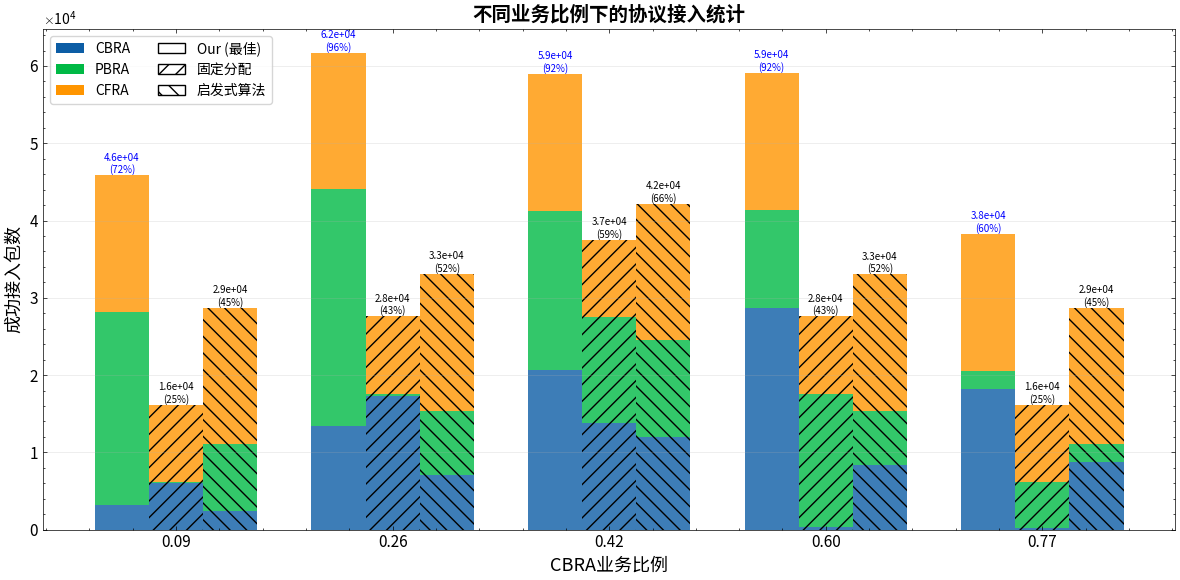

比例扫描对比图已保存到: output/static/ratio_sweep_comparison.svg


In [9]:
def plot_ratio_sweep_results():
    """绘制比例扫描实验结果 - 单图柱状图，X轴为比例，Legend为策略"""
    # 提取数据
    cbra_ratios = []

    # 各策略的各协议成功数
    ppo_cbra = []
    ppo_pbra = []
    ppo_cfra = []
    ppo_theo = []
    fixed_cbra = []
    fixed_pbra = []
    fixed_cfra = []
    fixed_theo = []
    heuristic_cbra = []
    heuristic_pbra = []
    heuristic_cfra = []
    heuristic_theo = []

    for scenario_name, result in all_scenarios_results.items():
        if scenario_name.startswith("RatioSweep"):
            parts = scenario_name.split('_')
            cbra_ratio = float(parts[1][1:])

            cbra_ratios.append(cbra_ratio)

            # PPO最佳模型 (选择 best 或 last 中总成功数更高的)
            best_total_succ = (result['eval_results_best']['eval_success_cbra'] +
                             result['eval_results_best']['eval_success_pbra'] +
                             result['eval_results_best']['eval_success_cfra'])
            last_total_succ = (result['eval_results_last']['eval_success_cbra'] +
                             result['eval_results_last']['eval_success_pbra'] +
                             result['eval_results_last']['eval_success_cfra'])
            ppo_choice = 'eval_results_best' if best_total_succ >= last_total_succ else 'eval_results_last'

            # PPO结果
            ppo_cbra.append(result[ppo_choice]['eval_success_cbra'])
            ppo_pbra.append(result[ppo_choice]['eval_success_pbra'])
            ppo_cfra.append(result[ppo_choice]['eval_success_cfra'])
            ppo_theo.append(result[ppo_choice].get('eval_theoretical_optimal', 0))

            # 固定分配
            fixed_cbra.append(result['baseline_results']['固定分配']['success_cbra'])
            fixed_pbra.append(result['baseline_results']['固定分配']['success_pbra'])
            fixed_cfra.append(result['baseline_results']['固定分配']['success_cfra'])
            fixed_theo.append(result['baseline_results']['固定分配'].get('theoretical_optimal', 0))

            # 启发式算法
            heuristic_cbra.append(result['baseline_results']['启发式算法']['success_cbra'])
            heuristic_pbra.append(result['baseline_results']['启发式算法']['success_pbra'])
            heuristic_cfra.append(result['baseline_results']['启发式算法']['success_cfra'])
            heuristic_theo.append(result['baseline_results']['启发式算法'].get('theoretical_optimal', 0))

    # 排序
    sorted_indices = np.argsort(cbra_ratios)
    cbra_ratios = np.array(cbra_ratios)[sorted_indices]
    ppo_cbra = np.array(ppo_cbra)[sorted_indices]
    ppo_pbra = np.array(ppo_pbra)[sorted_indices]
    ppo_cfra = np.array(ppo_cfra)[sorted_indices]
    ppo_theo = np.array(ppo_theo)[sorted_indices]
    fixed_cbra = np.array(fixed_cbra)[sorted_indices]
    fixed_pbra = np.array(fixed_pbra)[sorted_indices]
    fixed_cfra = np.array(fixed_cfra)[sorted_indices]
    fixed_theo = np.array(fixed_theo)[sorted_indices]
    heuristic_cbra = np.array(heuristic_cbra)[sorted_indices]
    heuristic_pbra = np.array(heuristic_pbra)[sorted_indices]
    heuristic_cfra = np.array(heuristic_cfra)[sorted_indices]
    heuristic_theo = np.array(heuristic_theo)[sorted_indices]

    # 计算总数
    ppo_total = ppo_cbra + ppo_pbra + ppo_cfra
    fixed_total = fixed_cbra + fixed_pbra + fixed_cfra
    heuristic_total = heuristic_cbra + heuristic_pbra + heuristic_cfra

    # 创建单图
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    os.makedirs("output/static", exist_ok=True)

    # 设置柱状图参数
    x = np.arange(len(cbra_ratios))
    width = 0.25

    # 绘制三组堆叠柱状图
    # Our (最佳)
    p1_cbra = ax.bar(x - width, ppo_cbra, width, alpha=0.8, color='C0')
    p1_pbra = ax.bar(x - width, ppo_pbra, width, bottom=ppo_cbra, alpha=0.8, color='C1')
    p1_cfra = ax.bar(x - width, ppo_cfra, width, bottom=ppo_cbra+ppo_pbra, alpha=0.8, color='C2')

    # 固定分配
    p2_cbra = ax.bar(x, fixed_cbra, width, alpha=0.8, color='C0', hatch='//')
    p2_pbra = ax.bar(x, fixed_pbra, width, bottom=fixed_cbra, alpha=0.8, color='C1', hatch='//')
    p2_cfra = ax.bar(x, fixed_cfra, width, bottom=fixed_cbra+fixed_pbra, alpha=0.8, color='C2', hatch='//')

    # 启发式算法
    p3_cbra = ax.bar(x + width, heuristic_cbra, width, alpha=0.8, color='C0', hatch='\\\\')
    p3_pbra = ax.bar(x + width, heuristic_pbra, width, bottom=heuristic_cbra, alpha=0.8, color='C1', hatch='\\\\')
    p3_cfra = ax.bar(x + width, heuristic_cfra, width, bottom=heuristic_cbra+heuristic_pbra, alpha=0.8, color='C2', hatch='\\\\')

    # 标注总数和达最优率
    for i in range(len(cbra_ratios)):
        if ppo_total[i] > 0:
            theo_rate = (ppo_total[i] / ppo_theo[i] * 100) if ppo_theo[i] > 0 else 0
            ax.text(i - width, ppo_total[i], f'{ppo_total[i]:.1e}\n({theo_rate:.0f}%)',
                   ha='center', va='bottom', fontsize=7, color='blue')
        if fixed_total[i] > 0:
            theo_rate = (fixed_total[i] / fixed_theo[i] * 100) if fixed_theo[i] > 0 else 0
            ax.text(i, fixed_total[i], f'{fixed_total[i]:.1e}\n({theo_rate:.0f}%)',
                   ha='center', va='bottom', fontsize=7)
        if heuristic_total[i] > 0:
            theo_rate = (heuristic_total[i] / heuristic_theo[i] * 100) if heuristic_theo[i] > 0 else 0
            ax.text(i + width, heuristic_total[i], f'{heuristic_total[i]:.1e}\n({theo_rate:.0f}%)',
                   ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('CBRA业务比例', fontsize=13)
    ax.set_ylabel('成功接入包数', fontsize=13)
    ax.set_title('不同业务比例下的协议接入统计', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r:.2f}' for r in cbra_ratios], fontsize=10)

    # 创建自定义图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='C0', label='CBRA'),
        Patch(facecolor='C1', label='PBRA'),
        Patch(facecolor='C2', label='CFRA'),
        Patch(facecolor='white', edgecolor='black', label='Our (最佳)'),
        Patch(facecolor='white', edgecolor='black', hatch='//', label='固定分配'),
        Patch(facecolor='white', edgecolor='black', hatch='\\\\', label='启发式算法'),
    ]
    ax.legend(handles=legend_elements, fontsize=10, frameon=True, loc='upper left', ncol=2)

    ax.tick_params(labelsize=11)
    ax.ticklabel_format(style='scientific', axis='y', scilimits=(0,0))
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig("output/static/ratio_sweep_comparison.svg", bbox_inches='tight', dpi=300)
    plt.show()
    print("比例扫描对比图已保存到: output/static/ratio_sweep_comparison.svg")

# 绘制结果
plot_ratio_sweep_results()


In [11]:
import os
import json
import numpy as np

def make_serializable(obj):
    """Recursively convert numpy types and arrays into Python built-ins for JSON serialization."""
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_serializable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

os.makedirs('output/static', exist_ok=True)
out_path = os.path.join('output', 'static', 'ratio_scenarios_results.json')
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(make_serializable(all_scenarios_results), f, ensure_ascii=False, indent=2)
print(f"Saved all_scenarios_results -> {out_path}")


Saved all_scenarios_results -> output\static\ratio_scenarios_results.json
